In [1]:
import numpy as np
import matplotlib.pyplot as plt
from genflows.utils.plotting_lobes import custom_cmap

## Load Data

In [2]:
h = np.load('results/height_sweep.npz')
r = np.load('results/radius_sweep.npz')

h_samples, h_vals = h['samples'], h['values']  # (N, 50, 50, 50)
r_samples, r_vals = r['samples'], r['values']

print(f'Height sweep: {len(h_vals)} samples, values = {h_vals}')
print(f'Radius sweep: {len(r_vals)} samples, values = {r_vals}')

Height sweep: 15 samples, values = [ 5.  10.  15.  20.  23.  24.  24.5 25.  25.5 26.  27.  30.  35.  40.
 45. ]
Radius sweep: 13 samples, values = [ 3.   6.  10.  13.  15.  16.  16.5 17.  18.  20.  23.  27.  30. ]


## Height Sweep — XZ Cross-Sections (at Y=25)
Vertical slices through the middle. X horizontal, Z(depth) vertical.

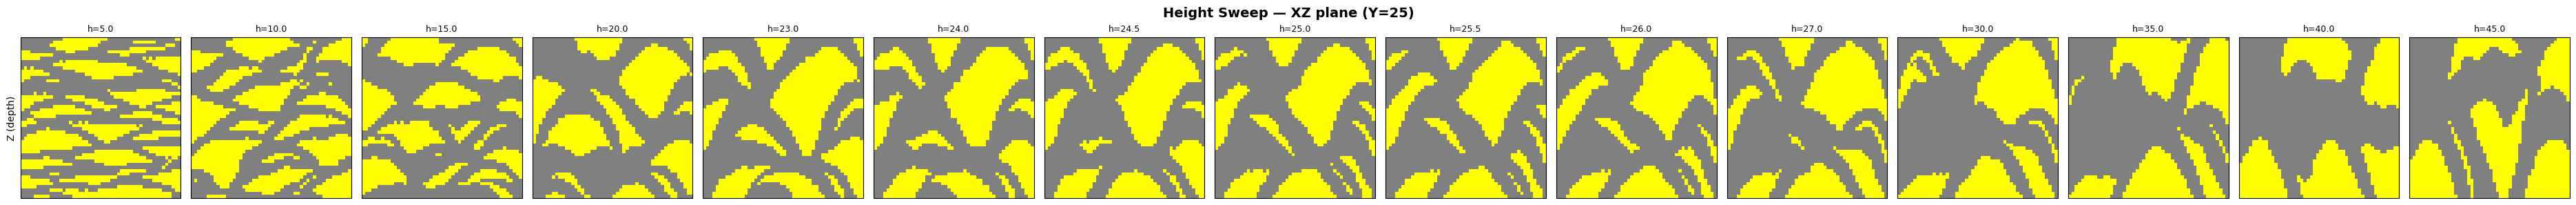

In [3]:
y_slice = 25
n = len(h_vals)
fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
fig.suptitle(f'Height Sweep — XZ plane (Y={y_slice})', fontsize=14, fontweight='bold')

for i, (ax, val) in enumerate(zip(axes, h_vals)):
    slc = h_samples[i, :, y_slice, :].T  # (Z, X)
    ax.imshow(slc, cmap=custom_cmap, vmin=0, vmax=1, origin='lower', aspect='equal')
    ax.set_title(f'h={val:.1f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if i == 0:
        ax.set_ylabel('Z (depth)')

plt.tight_layout()
plt.show()

## Height Sweep — XY Cross-Sections (at Z=25)
Horizontal slices at mid-depth.

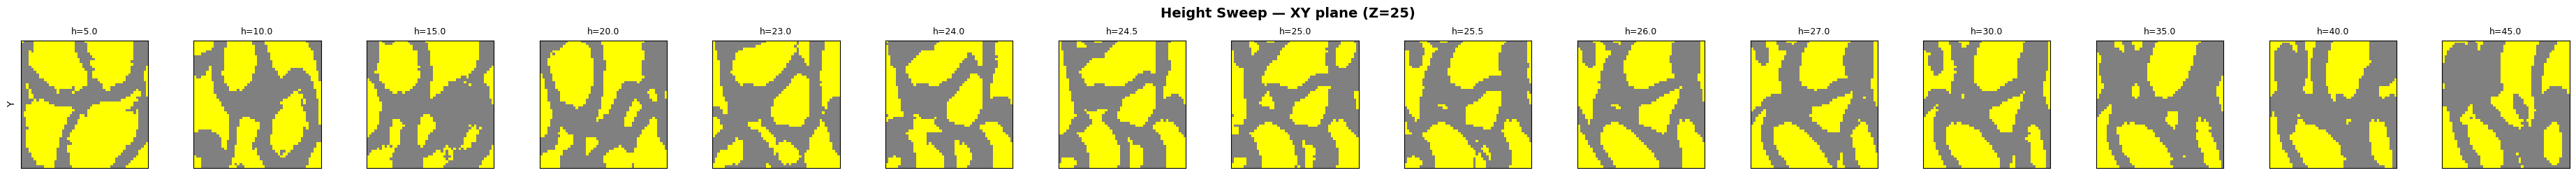

In [4]:
z_slice = 25
n = len(h_vals)
fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 2.5))
fig.suptitle(f'Height Sweep — XY plane (Z={z_slice})', fontsize=14, fontweight='bold')

for i, (ax, val) in enumerate(zip(axes, h_vals)):
    slc = h_samples[i, :, :, z_slice].T  # (Y, X)
    ax.imshow(slc, cmap=custom_cmap, vmin=0, vmax=1, origin='lower', aspect='equal')
    ax.set_title(f'h={val:.1f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if i == 0:
        ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

## Radius Sweep — XZ Cross-Sections (at Y=25)

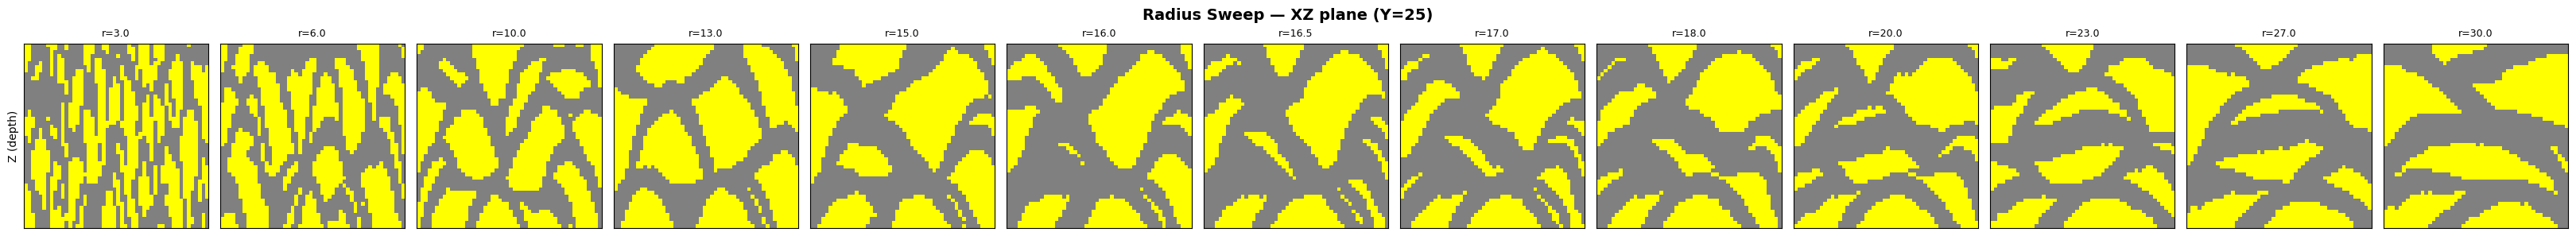

In [5]:
y_slice = 25
n = len(r_vals)
fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
fig.suptitle(f'Radius Sweep — XZ plane (Y={y_slice})', fontsize=14, fontweight='bold')

for i, (ax, val) in enumerate(zip(axes, r_vals)):
    slc = r_samples[i, :, y_slice, :].T  # (Z, X)
    ax.imshow(slc, cmap=custom_cmap, vmin=0, vmax=1, origin='lower', aspect='equal')
    ax.set_title(f'r={val:.1f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if i == 0:
        ax.set_ylabel('Z (depth)')

plt.tight_layout()
plt.show()

## Radius Sweep — XY Cross-Sections (at Z=25)

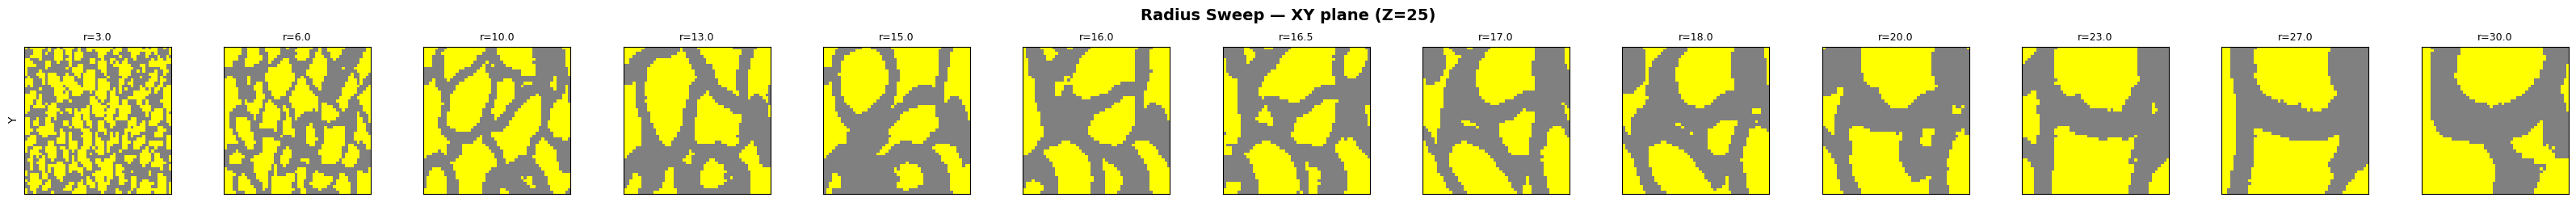

In [6]:
z_slice = 25
n = len(r_vals)
fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 2.5))
fig.suptitle(f'Radius Sweep — XY plane (Z={z_slice})', fontsize=14, fontweight='bold')

for i, (ax, val) in enumerate(zip(axes, r_vals)):
    slc = r_samples[i, :, :, z_slice].T  # (Y, X)
    ax.imshow(slc, cmap=custom_cmap, vmin=0, vmax=1, origin='lower', aspect='equal')
    ax.set_title(f'r={val:.1f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if i == 0:
        ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

## Per-Sample NTG

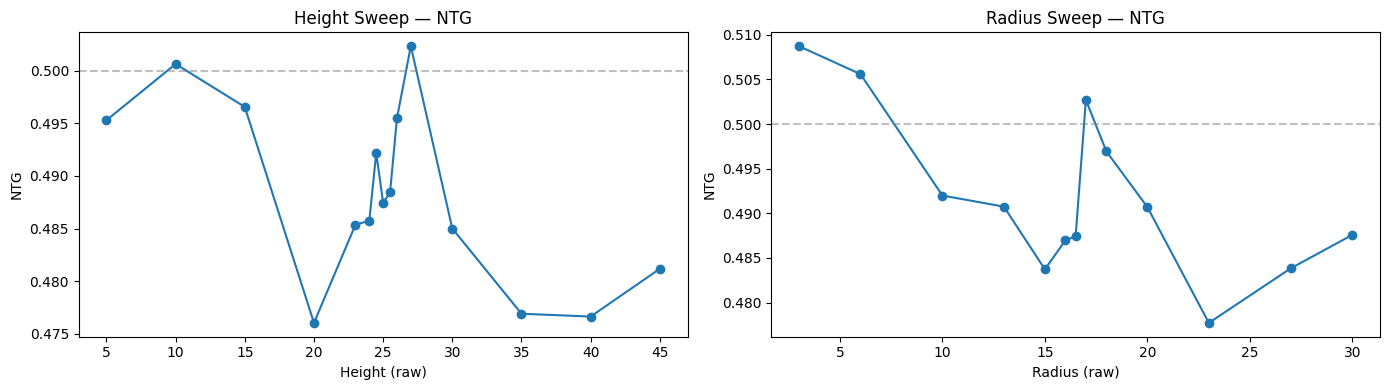

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

h_ntg = [h_samples[i].mean() for i in range(len(h_vals))]
axes[0].plot(h_vals, h_ntg, 'o-')
axes[0].set_xlabel('Height (raw)')
axes[0].set_ylabel('NTG')
axes[0].set_title('Height Sweep — NTG')
axes[0].axhline(0.5, ls='--', color='gray', alpha=0.5)

r_ntg = [r_samples[i].mean() for i in range(len(r_vals))]
axes[1].plot(r_vals, r_ntg, 'o-')
axes[1].set_xlabel('Radius (raw)')
axes[1].set_ylabel('NTG')
axes[1].set_title('Radius Sweep — NTG')
axes[1].axhline(0.5, ls='--', color='gray', alpha=0.5)

plt.tight_layout()
plt.show()